# Explanatory Data Analysis for Sensor-Based Analysis of Appliance Energy Consumption in a Low-Energy House



## Introduction
The notebook utilizes the Appliances Energy Prediction dataset, which is a publicly available dataset from the research paper provided below:

Research Paper: Candanedo, L. M., Feldheim, V., & Deramaix, D. (2017). Data driven prediction models of energy use of appliances in a low-energy house. Energy and Buildings, 140, 81–97. https://doi.org/10.1016/j.enbuild.2017.01.083
Dataset URL: https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction

Goal: The major aim of this analysis is to investigate household appliance energy consumption based on sensor data and weather related factors. Though the idea is based on the above referenced research paper, the analysis is intended to be more of an exploratory and explanatory data analysis workflow for a client, rather than purely predictive modeling.

## 1. Business Context
The client is a smart home energy management company and they help people save money on their bills and make their homes more energy efficient. They collect data from various rooms as well as weather-related variables and appliance-related variables.

The client is interested in understanding:
At what time appliance energy consumption is high.
What rooms are more related to high energy consumption.
Whether indoor sensor data is useful in explaining this data.
What actions should be recommended to save energy.

In this context, this dataset is very relevant to the client, and this notebook is useful for their business decision-making, given that it contains:
appliance_energy_usage
lighting_energy_usage
indoor_temperature and humidity from various rooms
weather-related variables
date and time variables

In [131]:
#import libraries and dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)

df=pd.read_csv('/content/energydata_complete.csv')

# ensure the target column is named 'Appliances' consistently
if 'Appliances' not in df.columns:
    if 'appliances' in df.columns:
        df.rename(columns={'appliances': 'Appliances'}, inplace=True)

df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,55.20,7.026667,84.256667,17.200000,41.626667,18.2,48.900000,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,55.20,6.833333,84.063333,17.200000,41.560000,18.2,48.863333,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,55.09,6.560000,83.156667,17.200000,41.433333,18.2,48.730000,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,55.09,6.433333,83.423333,17.133333,41.290000,18.1,48.590000,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,55.09,6.366667,84.893333,17.200000,41.230000,18.1,48.590000,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


## 2. Data Exploration
This section checks the basic structure and quality of the dataset before starting any major analysis.

In [132]:
# check number of features as number of columns and review dataset
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape of dataset: (19735, 29)

Columns:
['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1', 'rv2']


In [133]:
#check duplicate, missing values and datatypes
info_df = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_values': df.isna().sum(),
    'n_unique': df.nunique()
})
info_df

,dtype,missing_values,n_unique
date,object,0,19735
Appliances,int64,0,92
lights,int64,0,8
T1,float64,0,722
RH_1,float64,0,2547
T2,float64,0,1650
RH_2,float64,0,3376
T3,float64,0,1426
RH_3,float64,0,2618
T4,float64,0,1390


In [134]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Appliances,19735.0,97.694958,102.524891,10.000000,50.000000,60.000000,100.000000,1080.000000
lights,19735.0,3.801875,7.935988,0.000000,0.000000,0.000000,0.000000,70.000000
T1,19735.0,21.686571,1.606066,16.790000,20.760000,21.600000,22.600000,26.260000
RH_1,19735.0,40.259739,3.979299,27.023333,37.333333,39.656667,43.066667,63.360000
T2,19735.0,20.341219,2.192974,16.100000,18.790000,20.000000,21.500000,29.856667
RH_2,19735.0,40.420420,4.069813,20.463333,37.900000,40.500000,43.260000,56.026667
T3,19735.0,22.267611,2.006111,17.200000,20.790000,22.100000,23.290000,29.236000
RH_3,19735.0,39.242500,3.254576,28.766667,36.900000,38.530000,41.760000,50.163333
T4,19735.0,20.855335,2.042884,15.100000,19.530000,20.666667,22.100000,26.200000
RH_4,19735.0,39.026904,4.341321,27.660000,35.530000,38.400000,42.156667,51.090000


In [135]:
duplicates = df.duplicated().sum() #check duplicates columns
print("Duplicate rows:", duplicates)

Duplicate rows: 0


From a business and analytical point of view the dataset appears to be interesting as it contains a variety of variables such as: time variables, indoor sensor variables, weather variables and energy variables. This variety of variables enables both descriptive and decision-oriented analysis. The dataset also appears to be sufficiently large for pattern analysis.

# 3. Data Preprocessing
Before answering any business questions, data cleaning and imrpovement operations are necessary and in this case, the date-related columns have to be transformed into useful time features since many smart home related decisions are time dependent.

In [136]:
# create a clean copy of dataset
data = df.copy();

# parse date column as it's useful feature for usage based on datetime
data['date'] = pd.to_datetime(data['date'], format='mixed');

# create useful time-based features
data['year'] = data['date'].dt.year;
data['month'] = data['date'].dt.month;
data['month_name'] = data['date'].dt.month_name();
data['day'] = data['date'].dt.day;
data['day_name'] = data['date'].dt.day_name();
data['hour'] = data['date'].dt.hour;
data['minute'] = data['date'].dt.minute;
data['is_weekend'] = data['day_name'].isin(['Saturday', 'Sunday']);

# create combined indoor temperature and humidity indicators to analysed data
temp_cols = [c for c in data.columns if c.startswith('T')];
humidity_cols = [c for c in data.columns if c.startswith('RH_')];

data['avg_indoor_temp'] = data[temp_cols].mean(axis=1);
data['avg_indoor_humidity'] = data[humidity_cols].mean(axis=1);

# consumption levels for easier understanding
data['high_consumption'] = np.where(data['Appliances'] >= data['Appliances'].quantile(0.75), 'High', 'Normal')

print("Prepared data shape:", data.shape)
data[['date', 'Appliances', 'hour', 'day_name', 'is_weekend', 'avg_indoor_temp', 'avg_indoor_humidity', 'high_consumption']].head()

Prepared data shape: (19735, 40)


,date,Appliances,hour,day_name,is_weekend,avg_indoor_temp,avg_indoor_humidity,high_consumption
0,2016-01-11 17:00:00,60,17,Monday,False,15.127879,55.019667,Normal
1,2016-01-11 17:10:00,60,17,Monday,False,15.093636,54.944500,Normal
2,2016-01-11 17:20:00,50,17,Monday,False,15.036364,54.766000,Normal
3,2016-01-11 17:30:00,50,17,Monday,False,14.986667,54.717333,Normal
4,2016-01-11 17:40:00,60,17,Monday,False,14.970000,54.859667,Normal


In [137]:
# data quality check
print("How many missing values after preprocessing:", data.isna().sum().sum());
print("How many duplicate rows after preprocessing:", data.duplicated().sum());

How many missing values after preprocessing: 0
How many duplicate rows after preprocessing: 0


The preprocessing stage adds business friendly variables that make the analysis more practical for the business. For instance, the energy management company can now act on the analysis that indicates the hours of the day with high consumption and the fact that it is a weekend or a weekday, this will help the company understand much more easily than the actual timestamp.

# 4. Explanatory Data Analysis and Business Questions

The following section answers eight business questions. Each of the questions has been asked from the client's point of view. Code, results and interpretation have been provided for each of the questions.

### Question 1: At what times of day is appliance energy consumption highest?
If the company can determine what hours of the day typically have the highest demand for energy, it can even recommend that households shift flexible activities to off-peak hours or alert users during peak demand hours.

In [138]:
hourly_usage = data.groupby('hour')['Appliances'].mean().sort_index();
hourly_usage

,Appliances
hour,
0,52.785888
1,51.326034
2,49.075426
3,48.236010
4,49.355231
5,52.737226
6,57.712895
7,78.649635
8,106.143552


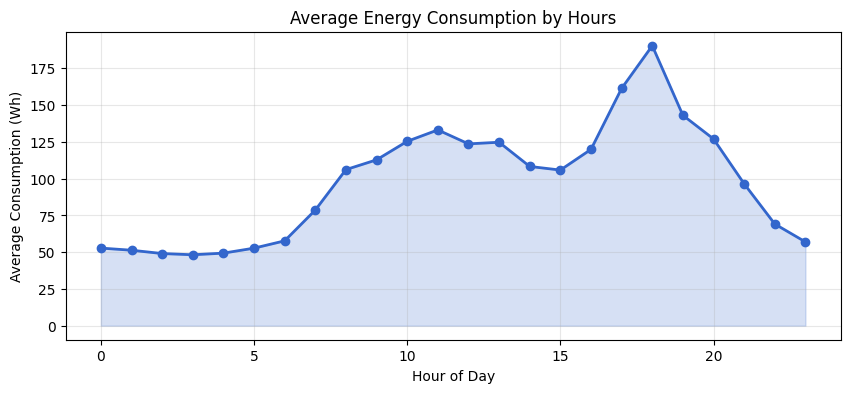

In [139]:
plt.figure(figsize=(10,4))
plt.plot(hourly_usage.index, hourly_usage.values, marker='o', color='#3366CC', linewidth=2)
plt.fill_between(hourly_usage.index, hourly_usage.values, color='#3366CC', alpha=0.2)
plt.title('Average Energy Consumption by Hours')
plt.xlabel('Hour of Day')
plt.ylabel('Average Consumption (Wh)')
plt.grid(True, alpha=0.3)
plt.show()

Interpretation: The output of this result is to identify the daily pattern of appliances consumption. The peaks of this result identify the hours when households are most active. This is important when generating smart alerts, suggestions, and advice.

### Question 2: Do weekends and weekdays show different energy usage patterns?
The behavior of users may vary during weekends. If there is a clear distinction in usage patterns during weekends and weekdays, the client company may develop separate energy saving plans for weekends and weekdays.

In [140]:
week_usage = data.groupby('is_weekend')['Appliances'].agg(['mean', 'median', 'max', 'count']);
week_usage.index = ['Weekdays', 'Weekend'];
week_usage

,mean,median,max,count
Weekdays,96.587674,60.0,1070,14263
Weekend,100.581140,70.0,1080,5472


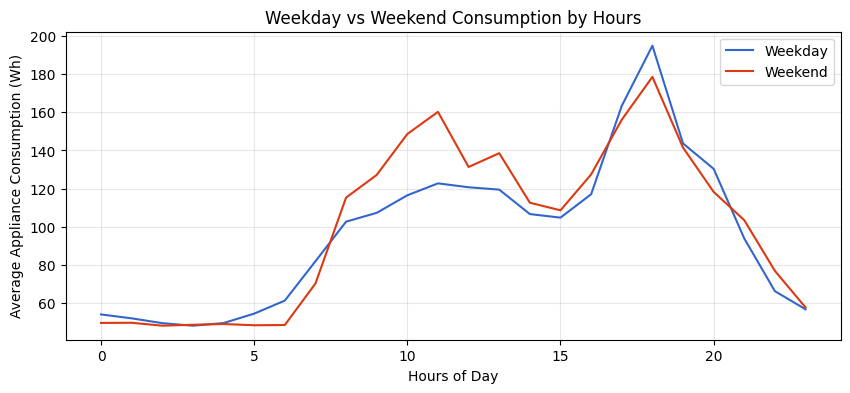

In [141]:
weekday_hours = data.groupby(['is_weekend', 'hour'])['Appliances'].mean().unstack(0);
weekday_hours.columns = ['Weekday', 'Weekend'];

plt.figure(figsize=(10,4))
weekday_hours.plot(ax=plt.gca(),color=['#3366CC', '#DC3912']);
plt.title('Weekday vs Weekend Consumption by Hours');
plt.xlabel('Hours of Day');
plt.ylabel('Average Appliance Consumption (Wh)');
plt.grid(True, alpha=0.3);
plt.show();

Interpretation: This comparison of behavior during the week and at the weekend can help the client understand whether the users of the appliances differ during the periods when they are more likely to be at home.

### Question 3: Which indoor temperature sensors are most associated with appliance energy consumption?
The paper indicates that the readings from the indoor sensors may help improve the understanding of the usage of the appliances. Some rooms may be more related to the consumption of the appliance; hence, they may be more important for monitoring and controlling the appliance.

In [142]:
temp_columns = [c for c in data.columns if c.startswith('T')]
temp_correlation = data[temp_columns + ['Appliances']].corr()['Appliances'].drop('Appliances').sort_values(key=np.abs, ascending=False)
temp_correlation.to_frame('correlation_with_Appliances')

,correlation_with_Appliances
T2,0.120073
T6,0.117638
T_out,0.099155
T3,0.085060
T1,0.055447
T4,0.040281
T8,0.039572
T7,0.025801
T5,0.019760
Tdewpoint,0.015353


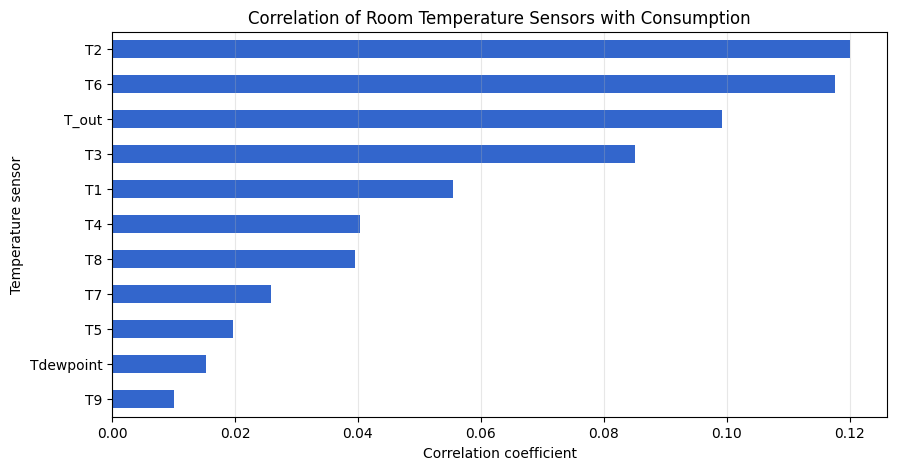

In [143]:
plt.figure(figsize=(10,5))
temp_correlation.sort_values().plot(kind='barh',color='#3366CC')
plt.title('Correlation of Room Temperature Sensors with Consumption')
plt.xlabel('Correlation coefficient')
plt.ylabel('Temperature sensor')
plt.grid(True, axis='x', alpha=0.3)
plt.show()

Interpretation: The strongest relationships at room temperature show where environmental changes vary most closely with appliance usage. This might help the client prioritize sensors in a space such as a kitchen, living area and laundry-related area.

### Question 4: Which indoor humidity sensors are most associated with appliance energy consumption?
Humidity may represent activity in the home such as cooking, washing, and room usage. If the humidity sensors are informative, this can be useful for enhanced monitoring and predictive systems in the future.

In [144]:
humidity_columns = [c for c in data.columns if c.startswith('RH_')]
humidity_correlation = data[humidity_columns + ['Appliances']].corr()['Appliances'].drop('Appliances').sort_values(key=np.abs, ascending=False)
humidity_correlation.to_frame('correlation_with_Appliances')

,correlation_with_Appliances
RH_out,-0.152282
RH_8,-0.094039
RH_1,0.086031
RH_6,-0.083178
RH_2,-0.060465
RH_7,-0.055642
RH_9,-0.051462
RH_3,0.036292
RH_4,0.016965
RH_5,0.006955


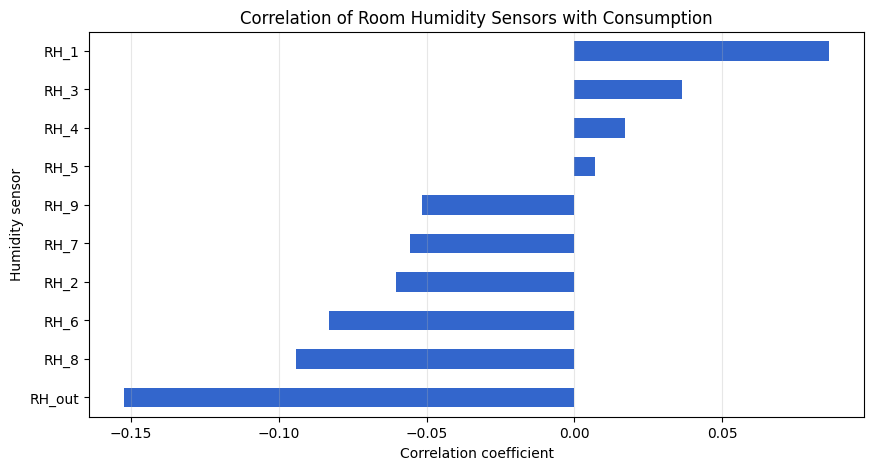

In [145]:
plt.figure(figsize=(10,5))
humidity_correlation.sort_values().plot(kind='barh', color='#3366CC')
plt.title('Correlation of Room Humidity Sensors with Consumption')
plt.xlabel('Correlation coefficient')
plt.ylabel('Humidity sensor')
plt.grid(True, axis='x', alpha=0.3)
plt.show()

Interpretation:Humidity based signals can provide usage patterns that are not clear from the energy signals. This again relates to the client’s assumption that homes with sensor systems provide better clarity on usage patterns than the energy signals themselves.

### Question 5: How does appliance consumption vary across days of the week?
Knowing the most energy-intensive days can also help the client target behavior change, especially if there are particular routines on particular days.

In [146]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_usage = data.groupby('day_name')['Appliances'].mean().reindex(day_order)
daily_usage

,Appliances
day_name,
Monday,111.450684
Tuesday,87.125000
Wednesday,89.930556
Thursday,90.434028
Friday,104.622144
Saturday,106.246345
Sunday,94.915936


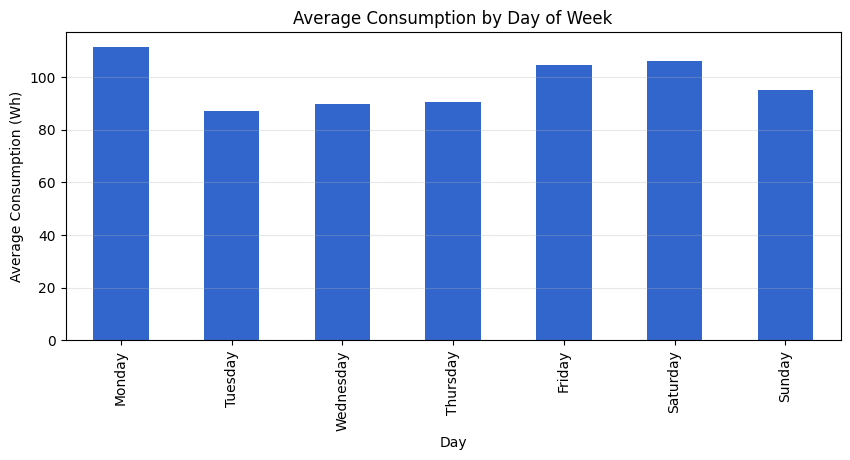

In [147]:
plt.figure(figsize=(10,4))
daily_usage.plot(kind='bar',color='#3366CC')
plt.title('Average Consumption by Day of Week')
plt.xlabel('Day')
plt.ylabel('Average Consumption (Wh)')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

Interpretation: The above analysis shows if the consumption is uniformly distributed throughout the week or if there are specific days when consumption happens. This may be helpful in sending specific-day-based notifications or suggestions to shift loads.

### Question 6: What weather conditions are most related to appliance energy use?
Weather may play a role in influencing indoor activities, which in turn may affect appliances. If specific weather conditions are associated with increased consumption, the company may provide weather-based suggestions.

In [148]:
weather_columns = ['T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint']
weather_correlation = data[weather_columns + ['Appliances']].corr()['Appliances'].drop('Appliances').sort_values(key=np.abs, ascending=False)
weather_correlation.to_frame('correlation_with_Appliances')

,correlation_with_Appliances
RH_out,-0.152282
T_out,0.099155
Windspeed,0.087122
Press_mm_hg,-0.034885
Tdewpoint,0.015353
Visibility,0.000230


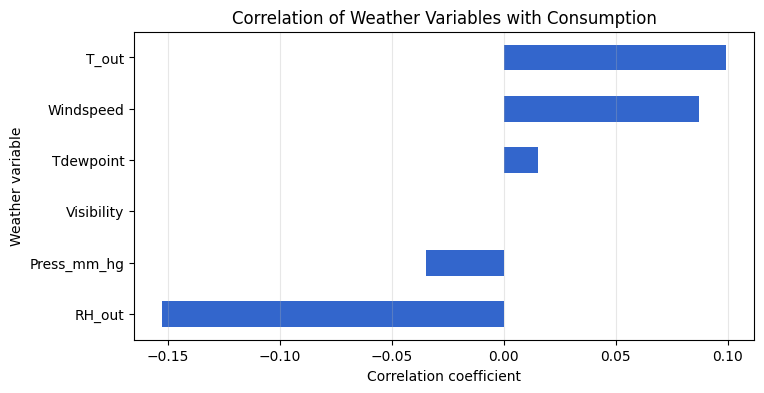

In [149]:
plt.figure(figsize=(8,4))
weather_correlation.sort_values().plot(kind='barh',color='#3366CC')
plt.title('Correlation of Weather Variables with Consumption')
plt.xlabel('Correlation coefficient')
plt.ylabel('Weather variable')
plt.grid(True, axis='x', alpha=0.3)
plt.show()

Interpretation:If the consumption of some weather variables is higher than that of others, the client may use the nudges triggered by the weather. For instance, the consumer may receive more suggestions during such times.

### Question 7: What characterizes high-consumption periods?
The client does not only want to know the averages. They want to know what makes a high usage period different from a normal period. This can be helpful in providing intervention and customer recommendations.

In [150]:
high_vs_normal = data.groupby('high_consumption')[['Appliances', 'lights', 'avg_indoor_temp', 'avg_indoor_humidity', 'T_out', 'RH_out', 'Windspeed']].mean()
high_vs_normal

,Appliances,lights,avg_indoor_temp,avg_indoor_humidity,T_out,RH_out,Windspeed
high_consumption,,,,,,,
High,212.308578,7.004414,17.332635,45.073652,8.583337,74.690910,4.418037
Normal,56.573258,2.652850,16.708732,46.894234,6.991286,81.565696,3.904029


In [151]:
high_share_by_hour = pd.crosstab(data['hour'], data['high_consumption'], normalize='index') * 100
high_share_by_hour

high_consumption,High,Normal
hour,,
0,0.851582,99.148418
1,0.364964,99.635036
2,0.000000,100.000000
3,0.000000,100.000000
4,0.000000,100.000000
5,1.703163,98.296837
6,4.136253,95.863747
7,11.800487,88.199513
8,25.425791,74.574209


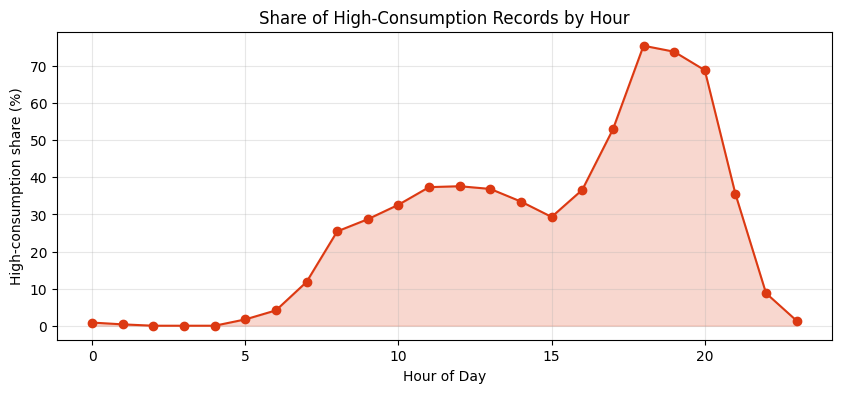

In [152]:
plt.figure(figsize=(10,4))
plt.plot(high_share_by_hour.index, high_share_by_hour['High'], marker='o', color='#DC3912')
plt.fill_between(high_share_by_hour.index, high_share_by_hour['High'], color='#DC3912', alpha=0.2)
plt.title('Share of High-Consumption Records by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('High-consumption share (%)')
plt.grid(True, alpha=0.3)
plt.show()

Interpretation: In this section, high-consumption periods are compared with normal usage patterns and the times of day when high-consumption events are most likely to occur are identified. This information is useful in setting up alerts, defining automation and providing guidance to customers.

### Question 8: What variables are most strongly related to appliance energy consumption in general?
The client is interested in getting a general overview of what variables are most informative in relation to appliance energy consumption. This is useful to get a better understanding of what variables should be monitored, and what variables might be useful in a forecasting model in the future.

In [153]:
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()
overall_correlation = data[numeric_columns].corr()['Appliances'].drop('Appliances').sort_values(key=np.abs, ascending=False)
overall_correlation.head(15).to_frame('correlation_with_Appliances')

,correlation_with_Appliances
hour,0.216792
lights,0.197278
RH_out,-0.152282
T2,0.120073
T6,0.117638
T_out,0.099155
RH_8,-0.094039
Windspeed,0.087122
RH_1,0.086031
avg_indoor_humidity,-0.085110


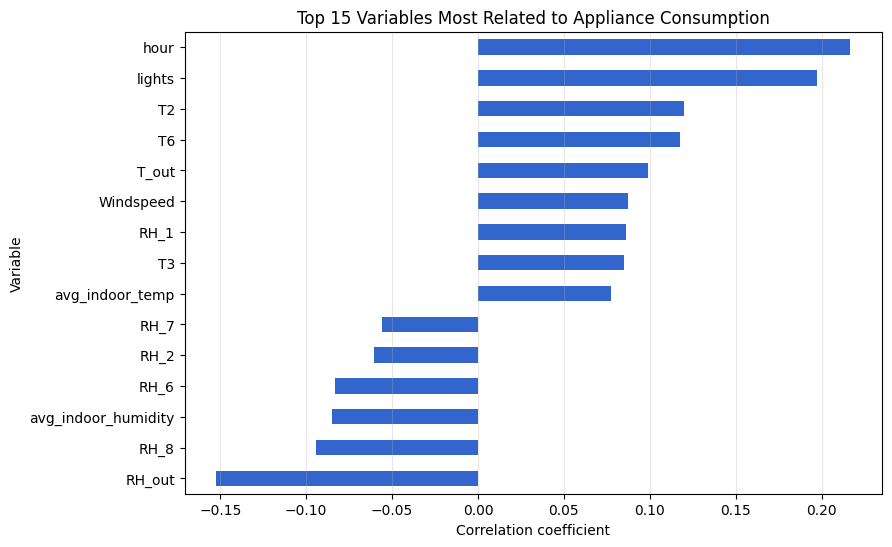

In [154]:
plt.figure(figsize=(9,6))
overall_correlation.head(15).sort_values().plot(kind='barh',color='#3366CC')
plt.title('Top 15 Variables Most Related to Appliance Consumption')
plt.xlabel('Correlation coefficient')
plt.ylabel('Variable')
plt.grid(True, axis='x', alpha=0.3)
plt.show()

Interpretation: This ranking gives a general overview of which variables are most relevant to appliance energy consumption. It is particularly useful for deciding upon features to be included in a dashboard, sensor investments, and future predictive models.

## 5. Outcomes: Do sensor variables improve a simple predictive model?
The source paper suggests that the accuracy of predictions can be increased with the use of temperature and humidity data from the wireless sensor network. To make this notebook more closely relate to the source paper, the simple baseline model is extended to include and exclude the indoor sensor network.

In [155]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# baseline features time and weather variables
baseline_features = ['hour', 'month', 'lights', 'T_out', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'Press_mm_hg']

# extended features indoor and sensor variables
extended_features = baseline_features + temp_columns + humidity_columns

# prepare train/test data split
target = data['Appliances']

X_base = data[baseline_features]
X_ext = data[extended_features]

Xb_train, Xb_test, y_train, y_test = train_test_split(X_base, target, test_size=0.2, random_state=42)
Xe_train, Xe_test, _, _ = train_test_split(X_ext, target, test_size=0.2, random_state=42)

base_model = LinearRegression()
ext_model = LinearRegression()

base_model.fit(Xb_train, y_train)
ext_model.fit(Xe_train, y_train)

base_pred = base_model.predict(Xb_test)
ext_pred = ext_model.predict(Xe_test)

comparison = pd.DataFrame({
    'Model': ['Baseline (time+weather)', 'Extended (time+weather+indoor sensors)'],
    'MAE': [mean_absolute_error(y_test, base_pred), mean_absolute_error(y_test, ext_pred)],
    'R2': [r2_score(y_test, base_pred), r2_score(y_test, ext_pred)]
})
comparison

,Model,MAE,R2
0,Baseline (time+weather),54.326533,0.097455
1,Extended (time+weather+indoor sensors),52.511302,0.172287


Interpretation: If the extended model performs better, it supports the same general idea reported in the paper: indoor sensor measurements contribute valuable information for understanding appliance energy consumption.

## 6. Conclusion
The analysis showed that appliance consumption can be examined not only as a technical target variable but also as a behaviourally meaningful business indicator.Overall, the notebook supports the idea presented in the source paper sensor and environmental data can improve understanding of appliance energy consumption. From a business perspective, this creates value by enabling more targeted, explainable and actionable smart-home energy insights.

## 7. Future Scope
Future research include enhancing the model’s accuracy by incorporating more meaningful features apart from the existing sensor and weather features used in the paper. Some features that can be incorporated include patterns of previous usage, occupancy, daily routines, weekend effects and others, which can enable the model to understand the actual usage behavior better.

## 8. References
Candanedo, L. M., Feldheim, V., & Deramaix, D. (2017). Data driven prediction models of energy use of appliances in a low-energy house. Energy and Buildings, 140, 81–97. https://doi.org/10.1016/j.enbuild.2017.01.083

Appliances Energy Prediction Available at: https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction